In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Define paths
RAW_DATA_DIR = Path('../data/raw')
PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../results/figures')

print("✅ Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded successfully!


## 1. Load Dữ Liệu Từ Các Nguồn

In [2]:
# Load all datasets
df_kaggle = pd.read_csv(RAW_DATA_DIR / 'stroke_kaggle.csv')
df_huggingface = pd.read_csv(RAW_DATA_DIR / 'stroke_huggingface.csv')
df_synthetic = pd.read_csv(RAW_DATA_DIR / 'stroke_synthetic.csv')

# Add source column
df_kaggle['source'] = 'kaggle'
df_huggingface['source'] = 'huggingface'
df_synthetic['source'] = 'synthetic'

print(f"Kaggle: {df_kaggle.shape}")
print(f"HuggingFace: {df_huggingface.shape}")
print(f"Synthetic: {df_synthetic.shape}")

Kaggle: (5110, 13)
HuggingFace: (5110, 13)
Synthetic: (500, 13)


## 2. Data Fusion - Tích Hợp Dữ Liệu

### 2.1 Kiểm Tra Mapping Cột

In [3]:
# Check columns alignment
print("📋 COLUMN MAPPING\n")
print(f"Kaggle columns: {df_kaggle.columns.tolist()}")
print(f"\nHuggingFace columns: {df_huggingface.columns.tolist()}")
print(f"\nSynthetic columns: {df_synthetic.columns.tolist()}")

# Check if columns match
common_cols = set(df_kaggle.columns) & set(df_huggingface.columns) & set(df_synthetic.columns)
print(f"\n✅ Common columns: {common_cols}")

📋 COLUMN MAPPING

Kaggle columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'source']

HuggingFace columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'source']

Synthetic columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'source']

✅ Common columns: {'Residence_type', 'avg_glucose_level', 'gender', 'heart_disease', 'work_type', 'ever_married', 'age', 'stroke', 'smoking_status', 'id', 'bmi', 'source', 'hypertension'}


### 2.2 Merge Datasets

In [4]:
# Concatenate all datasets
df_merged = pd.concat([df_kaggle, df_huggingface, df_synthetic], ignore_index=True)

print(f"📊 MERGED DATASET")
print(f"Shape: {df_merged.shape}")
print(f"\nSource distribution:")
print(df_merged['source'].value_counts())

📊 MERGED DATASET
Shape: (10720, 13)

Source distribution:
source
kaggle         5110
huggingface    5110
synthetic       500
Name: count, dtype: int64


In [5]:
# Remove duplicates (keeping first occurrence)
# Note: We'll use all columns except 'id' and 'source' for duplicate detection
cols_for_dup_check = [c for c in df_merged.columns if c not in ['id', 'source']]

print(f"Before removing duplicates: {len(df_merged)}")
df_merged = df_merged.drop_duplicates(subset=cols_for_dup_check, keep='first')
print(f"After removing duplicates: {len(df_merged)}")

Before removing duplicates: 10720
After removing duplicates: 5610


In [6]:
# Reset index and create new ID
df_merged = df_merged.reset_index(drop=True)
df_merged['id'] = range(1, len(df_merged) + 1)

print("✅ Data fusion completed!")
df_merged.head()

✅ Data fusion completed!


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,source
0,1,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,kaggle
1,2,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,kaggle
2,3,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,kaggle
3,4,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,kaggle
4,5,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,kaggle


## 3. Phân Tích Missing Data

### 3.1 Tỉ Lệ Missing Theo Cột

In [7]:
# Calculate missing values
missing_count = df_merged.isnull().sum()
missing_pct = (df_merged.isnull().sum() / len(df_merged) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

print("📊 MISSING DATA ANALYSIS\n")
missing_df[missing_df['Missing Count'] > 0]

📊 MISSING DATA ANALYSIS



,Column,Missing Count,Missing %
9,bmi,293,5.22


### 3.2 Visualization Missing Data

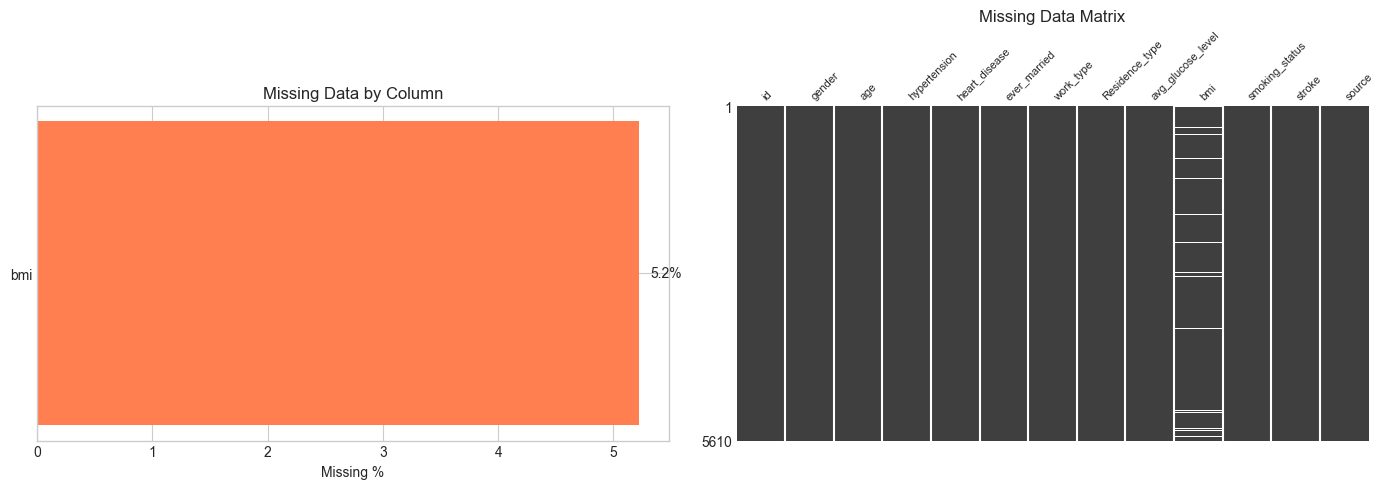


✅ Figure saved to results/figures/missing_data_analysis.png


In [8]:
# Missing data visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of missing percentages
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]['Column'].tolist()
if cols_with_missing:
    ax1 = axes[0]
    missing_subset = missing_df[missing_df['Missing Count'] > 0]
    ax1.barh(missing_subset['Column'], missing_subset['Missing %'], color='coral')
    ax1.set_xlabel('Missing %')
    ax1.set_title('Missing Data by Column')
    for i, v in enumerate(missing_subset['Missing %']):
        ax1.text(v + 0.1, i, f'{v:.1f}%', va='center')
else:
    axes[0].text(0.5, 0.5, 'No missing data', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Data by Column')

# Missing matrix using missingno
ax2 = axes[1]
msno.matrix(df_merged, ax=ax2, sparkline=False, fontsize=8)
ax2.set_title('Missing Data Matrix')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved to results/figures/missing_data_analysis.png")

### 3.3 Missing Data Pattern

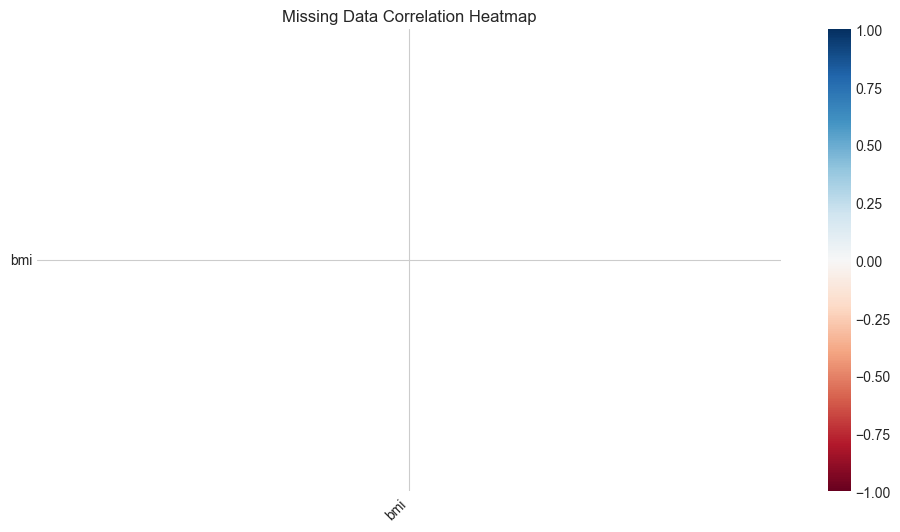

In [9]:
# Missing data heatmap
fig, ax = plt.subplots(figsize=(12, 6))
msno.heatmap(df_merged, ax=ax, fontsize=10)
ax.set_title('Missing Data Correlation Heatmap')
plt.savefig(FIGURES_DIR / 'missing_data_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Kiểm Tra Giá Trị Bất Hợp Lý (Outliers)

In [10]:
# Check for anomalies
print("🔍 KIỂM TRA GIÁ TRỊ BẤT HỢP LÝ\n")

# Age
print(f"Age range: {df_merged['age'].min()} - {df_merged['age'].max()}")
print(f"   Negative or zero: {(df_merged['age'] <= 0).sum()}")

# BMI
print(f"\nBMI range: {df_merged['bmi'].min()} - {df_merged['bmi'].max()}")
print(f"   BMI = 0: {(df_merged['bmi'] == 0).sum()}")
print(f"   BMI < 10 (too low): {(df_merged['bmi'] < 10).sum()}")
print(f"   BMI > 60 (extreme): {(df_merged['bmi'] > 60).sum()}")

# Glucose
print(f"\nGlucose range: {df_merged['avg_glucose_level'].min()} - {df_merged['avg_glucose_level'].max()}")
print(f"   Glucose <= 0: {(df_merged['avg_glucose_level'] <= 0).sum()}")
print(f"   Glucose > 300 (very high): {(df_merged['avg_glucose_level'] > 300).sum()}")

🔍 KIỂM TRA GIÁ TRỊ BẤT HỢP LÝ

Age range: 0.0 - 84.0
   Negative or zero: 9

BMI range: 10.3 - 97.6
   BMI = 0: 0
   BMI < 10 (too low): 0
   BMI > 60 (extreme): 13

Glucose range: 50.0 - 271.74
   Glucose <= 0: 0
   Glucose > 300 (very high): 0


In [11]:
# Check for 'Other' in gender (might want to handle)
print("\n📊 Gender distribution:")
print(df_merged['gender'].value_counts())


📊 Gender distribution:
gender
Female    3293
Male      2316
Other        1
Name: count, dtype: int64


## 5. Data Preprocessing

### 5.1 Remove 'Other' gender (only 1 sample)

In [12]:
# Remove 'Other' gender (too few samples)
df_clean = df_merged[df_merged['gender'] != 'Other'].copy()
print(f"Removed 'Other' gender. New shape: {df_clean.shape}")

Removed 'Other' gender. New shape: (5609, 13)


### 5.2 Encode Categorical Variables

In [13]:
# Define column types
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'stroke']

print("📋 Column Categories:")
print(f"Categorical: {categorical_cols}")
print(f"Numeric: {numeric_cols}")
print(f"Binary: {binary_cols}")

📋 Column Categories:
Categorical: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Numeric: ['age', 'avg_glucose_level', 'bmi']
Binary: ['hypertension', 'heart_disease', 'stroke']


In [14]:
# Create a copy for encoding
df_encoded = df_clean.copy()

# Label encoding for categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Handle missing values in categorical columns
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


## 6. Missing Data Pipelines

Tạo 3 phương pháp xử lý missing data:

| Pipeline | Mô tả | Phương pháp |
|----------|-------|-------------|
| **M0** | Baseline | Listwise deletion (xóa dòng có missing) |
| **M1** | Simple | Mean/Median imputation |
| **M2** | Advanced | KNN Imputation |

In [15]:
# Prepare feature columns for imputation
feature_cols = numeric_cols + [col + '_encoded' for col in categorical_cols]
all_cols = ['id'] + feature_cols + binary_cols + ['source']

# Base dataframe for pipelines
df_base = df_encoded[['id'] + numeric_cols + [col + '_encoded' for col in categorical_cols] + binary_cols + ['source']].copy()

print(f"Base dataframe shape: {df_base.shape}")
print(f"Missing in BMI: {df_base['bmi'].isnull().sum()}")

Base dataframe shape: (5609, 13)
Missing in BMI: 293


### Pipeline M0: Listwise Deletion

In [16]:
# M0: Listwise deletion - remove rows with any missing values
df_M0 = df_base.dropna().copy()
df_M0['pipeline'] = 'M0'

print("📊 Pipeline M0: Listwise Deletion")
print(f"Original shape: {df_base.shape}")
print(f"After deletion: {df_M0.shape}")
print(f"Rows removed: {len(df_base) - len(df_M0)} ({(len(df_base) - len(df_M0))/len(df_base)*100:.1f}%)")

📊 Pipeline M0: Listwise Deletion
Original shape: (5609, 13)
After deletion: (5316, 14)
Rows removed: 293 (5.2%)


### Pipeline M1: Simple Imputation (Mean/Median)

In [17]:
# M1: Simple imputation - Mean for numeric
df_M1 = df_base.copy()

# Impute numeric columns with median (more robust to outliers)
simple_imputer = SimpleImputer(strategy='median')
df_M1[numeric_cols] = simple_imputer.fit_transform(df_M1[numeric_cols])

df_M1['pipeline'] = 'M1'

print("📊 Pipeline M1: Simple Imputation (Median)")
print(f"Shape: {df_M1.shape}")
print(f"Missing values after imputation: {df_M1.isnull().sum().sum()}")

📊 Pipeline M1: Simple Imputation (Median)
Shape: (5609, 14)
Missing values after imputation: 0


### Pipeline M2: KNN Imputation

In [18]:
# M2: KNN Imputation
df_M2 = df_base.copy()

# KNN imputer (using 5 nearest neighbors)
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation on numeric columns
df_M2[numeric_cols] = knn_imputer.fit_transform(df_M2[numeric_cols])

df_M2['pipeline'] = 'M2'

print("📊 Pipeline M2: KNN Imputation (k=5)")
print(f"Shape: {df_M2.shape}")
print(f"Missing values after imputation: {df_M2.isnull().sum().sum()}")

📊 Pipeline M2: KNN Imputation (k=5)
Shape: (5609, 14)
Missing values after imputation: 0


### So Sánh Các Pipeline

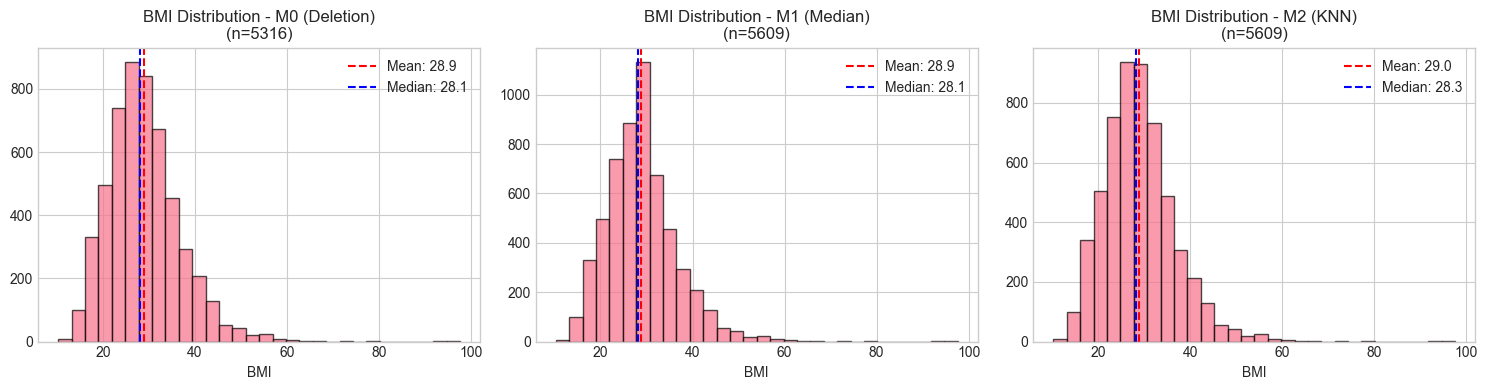


✅ Figure saved to results/figures/missing_pipeline_comparison.png


In [19]:
# Compare BMI distributions across pipelines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('M0 (Deletion)', df_M0), ('M1 (Median)', df_M1), ('M2 (KNN)', df_M2)]):
    ax.hist(df['bmi'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {df["bmi"].mean():.1f}')
    ax.axvline(df['bmi'].median(), color='blue', linestyle='--', label=f'Median: {df["bmi"].median():.1f}')
    ax.set_title(f'BMI Distribution - {name}\n(n={len(df)})')
    ax.set_xlabel('BMI')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved to results/figures/missing_pipeline_comparison.png")

In [20]:
# Summary statistics comparison
print("📊 BMI STATISTICS COMPARISON\n")
print(f"{'Pipeline':<12} {'Count':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("=" * 52)

for name, df in [('Original', df_base), ('M0', df_M0), ('M1', df_M1), ('M2', df_M2)]:
    bmi = df['bmi'].dropna()
    print(f"{name:<12} {len(df):<10} {bmi.mean():<10.2f} {bmi.median():<10.2f} {bmi.std():<10.2f}")

📊 BMI STATISTICS COMPARISON

Pipeline     Count      Mean       Median     Std       
Original     5609       28.92      28.10      7.82      
M0           5316       28.92      28.10      7.82      
M1           5609       28.87      28.10      7.61      
M2           5609       28.97      28.30      7.70      


## 7. Lưu Dữ Liệu Đã Xử Lý

In [21]:
# Save processed datasets
df_M0.to_csv(PROCESSED_DATA_DIR / 'stroke_M0.csv', index=False)
df_M1.to_csv(PROCESSED_DATA_DIR / 'stroke_M1.csv', index=False)
df_M2.to_csv(PROCESSED_DATA_DIR / 'stroke_M2.csv', index=False)

# Also save the merged clean data (before imputation) for reference
df_clean.to_csv(PROCESSED_DATA_DIR / 'stroke_merged_clean.csv', index=False)

# Save label encoders mapping
import json
encoder_mapping = {col: dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist())) 
                   for col, le in label_encoders.items()}
with open(PROCESSED_DATA_DIR / 'label_encoders.json', 'w') as f:
    json.dump(encoder_mapping, f, indent=2)

print("✅ Saved processed datasets:")
print(f"   - stroke_M0.csv ({len(df_M0)} rows)")
print(f"   - stroke_M1.csv ({len(df_M1)} rows)")
print(f"   - stroke_M2.csv ({len(df_M2)} rows)")
print(f"   - stroke_merged_clean.csv ({len(df_clean)} rows)")
print(f"   - label_encoders.json")

✅ Saved processed datasets:
   - stroke_M0.csv (5316 rows)
   - stroke_M1.csv (5609 rows)
   - stroke_M2.csv (5609 rows)
   - stroke_merged_clean.csv (5609 rows)
   - label_encoders.json


## 8. Tổng Kết

### ✅ Đã thực hiện:
1. **Data Fusion**: Tích hợp 3 nguồn dữ liệu, thêm cột `source`
2. **Missing Analysis**: Phân tích và visualize missing data
3. **Data Cleaning**: Loại bỏ giá trị 'Other' trong gender
4. **Encoding**: Label encoding cho biến categorical
5. **Missing Pipelines**:
   - M0: Listwise deletion
   - M1: Median imputation
   - M2: KNN imputation

### 📌 Bước tiếp theo:
- Notebook 3: EDA & Visualization
- Notebook 4: Modeling với các pipeline M* + I*

In [22]:
print("\n" + "=" * 60)
print("✅ DATA FUSION & CLEANING COMPLETE!")
print("=" * 60)
print("\nNext: Notebook 03 - EDA & Visualization")


✅ DATA FUSION & CLEANING COMPLETE!

Next: Notebook 03 - EDA & Visualization
